In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.stats import chi2

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10, 5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y) + 1)
    y_vals = y.values if hasattr(y, "values") else np.asarray(y)
    plt.plot(x_axis, y_vals, linewidth=1.2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_acf_pacf(y, nlags=18, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n // 2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10, 5))
    plt.stem(range(nlags + 1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.stem(range(nlags + 1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p


def plot_resid_acf(resid, nlags=18, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)
    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10, 5))
    plt.stem(range(nlags + 1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()


def ct_adf_kpss_report(y, regression_adf="ct", regression_kpss="ct"):
    yy = np.asarray(y)
    adf_res = adfuller(yy, regression=regression_adf, autolag="AIC")
    kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")
    out = pd.DataFrame({
        "test": ["ADF", "KPSS"],
        "statistic": [adf_res[0], kpss_res[0]],
        "p_value": [adf_res[1], kpss_res[1]],
        "null": ["unit root", "stationarity"]
    })
    return out

def c_adf_kpss_report(y, regression_adf="c", regression_kpss="c"):
    yy = np.asarray(y)
    adf_res = adfuller(yy, regression=regression_adf, autolag="AIC")
    kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")
    out = pd.DataFrame({
        "test": ["ADF", "KPSS"],
        "statistic": [adf_res[0], kpss_res[0]],
        "p_value": [adf_res[1], kpss_res[1]],
        "null": ["unit root", "stationarity"]
    })
    return out



def detrend_linear(y):
    yy = np.asarray(y)
    t = np.arange(1, len(yy) + 1)
    X = sm.add_constant(t)
    fit = sm.OLS(yy, X).fit()
    trend = fit.fittedvalues
    resid = fit.resid
    return fit, trend, resid


def select_arma_model(y, max_p=3, max_q=3, trend="n"):
    yy = np.asarray(y)
    rows = []
    fits = {}
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                fit = ARIMA(yy, order=(p, 0, q), trend=trend).fit()
                key = (p, 0, q)
                fits[key] = fit
                rows.append({
                    "order": key,
                    "AIC": float(fit.aic),
                    "BIC": float(fit.bic)
                })
            except Exception:
                pass
    grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    best_order = tuple(grid.loc[0, "order"])
    return fits[best_order], grid, fits


def residual_report(fit, lags=(6, 12, 18)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb


def arch_lm_test(resid, nlags=12):
    rr = np.asarray(resid)
    y = rr[nlags:] ** 2
    X = np.column_stack([rr[nlags - i - 1: -i - 1] ** 2 for i in range(nlags)])
    X = sm.add_constant(X)
    fit = sm.OLS(y, X).fit()
    lm = len(y) * fit.rsquared
    pval = 1 - chi2.cdf(lm, nlags)
    return {
        "LM statistic": lm,
        "df": nlags,
        "p_value": pval
    }


def _arch_variance(params, resid, q):
    omega = params[0]
    alpha = np.array(params[1:1+q])
    n = len(resid)
    sig2 = np.empty(n)
    unc = np.var(resid)
    for t in range(n):
        s = omega
        for i in range(1, q + 1):
            s += alpha[i - 1] * (resid[t - i] ** 2 if t - i >= 0 else unc)
        sig2[t] = max(s, 1e-8)
    return sig2


def _garch_variance(params, resid, p, q):
    omega = params[0]
    alpha = np.array(params[1:1+q])
    beta = np.array(params[1+q:])
    n = len(resid)
    sig2 = np.empty(n)
    unc = np.var(resid)
    denom = 1 - alpha.sum() - beta.sum()
    init = omega / denom if denom > 1e-6 else unc
    for t in range(n):
        s = omega
        for i in range(1, q + 1):
            s += alpha[i - 1] * (resid[t - i] ** 2 if t - i >= 0 else unc)
        for j in range(1, p + 1):
            s += beta[j - 1] * (sig2[t - j] if t - j >= 0 else init)
        sig2[t] = max(s, 1e-8)
    return sig2


def _arch_nll(params, resid, q):
    if params[0] <= 0 or np.any(np.array(params[1:]) < 0):
        return 1e12
    sig2 = _arch_variance(params, resid, q)
    return 0.5 * np.sum(np.log(sig2) + resid**2 / sig2)


def _garch_nll(params, resid, p, q):
    if params[0] <= 0 or np.any(np.array(params[1:]) < 0):
        return 1e12
    alpha = np.array(params[1:1+q])
    beta = np.array(params[1+q:])
    if alpha.sum() + beta.sum() >= 0.999:
        return 1e12
    sig2 = _garch_variance(params, resid, p, q)
    return 0.5 * np.sum(np.log(sig2) + resid**2 / sig2)


def fit_arch_model(resid, q=1):
    rr = np.asarray(resid)
    x0 = np.r_[0.1 * np.var(rr), np.repeat(0.1 / q, q)]
    bnds = [(1e-8, None)] * (q + 1)
    res = opt.minimize(_arch_nll, x0, args=(rr, q), method="L-BFGS-B", bounds=bnds)
    params = res.x
    sig2 = _arch_variance(params, rr, q)
    llf = -_arch_nll(params, rr, q)
    return {
        "model": f"ARCH({q})",
        "params": params,
        "sig2": sig2,
        "llf": llf,
        "AIC": -2 * llf + 2 * (q + 1),
        "success": res.success,
        "message": res.message
    }

#for log differencing, after finding best model with AIC and BIC, input optimal order and run the same
def fit_garch_model(resid, p=2, q=2):
    rr = np.asarray(resid)
    x0 = np.r_[0.05 * np.var(rr), np.repeat(0.05 / q, q), np.repeat(0.85 / p, p)]
    bnds = [(1e-8, None)] + [(0, 0.999)] * (p + q)
    res = opt.minimize(_garch_nll, x0, args=(rr, p, q), method="L-BFGS-B", bounds=bnds)
    params = res.x
    sig2 = _garch_variance(params, rr, p, q)
    llf = -_garch_nll(params, rr, p, q)
    return {
        "model": f"GARCH({p},{q})",
        "params": params,
        "sig2": sig2,
        "llf": llf,
        "AIC": -2 * llf + 2 * (1 + p + q),
        "success": res.success,
        "message": res.message
    }
#for simple differencing, after finding best model with AIC and BIC, input optimal order and run the same
def fit_diff_garch_model(resid, p=2, q=1):
    rr = np.asarray(resid)
    x0 = np.r_[0.05 * np.var(rr), np.repeat(0.05 / q, q), np.repeat(0.85 / p, p)]
    bnds = [(1e-8, None)] + [(0, 0.999)] * (p + q)
    res = opt.minimize(_garch_nll, x0, args=(rr, p, q), method="L-BFGS-B", bounds=bnds)
    params = res.x
    sig2 = _garch_variance(params, rr, p, q)
    llf = -_garch_nll(params, rr, p, q)
    return {
        "model": f"GARCH({p},{q})",
        "params": params,
        "sig2": sig2,
        "llf": llf,
        "AIC": -2 * llf + 2 * (1 + p + q),
        "success": res.success,
        "message": res.message
    }

def forecast_arch_variance(params, resid, q=1, h=12):
    omega = params[0]
    alpha = np.array(params[1:1+q])
    eps2 = list(np.asarray(resid) ** 2)
    out = []
    for _ in range(h):
        s = omega
        for i in range(1, q + 1):
            idx = len(eps2) - i
            s += alpha[i - 1] * (eps2[idx] if idx >= 0 else np.mean(eps2))
        out.append(s)
        eps2.append(s)
    return np.array(out)

#for log differencing, after finding best model with AIC and BIC, input optimal order and run the same,last value was till 17th April and we needed forecast till 24th April,if dataset is till 19th April put h as 5
def forecast_garch_variance(params, resid, sig2_hist, p=2, q=2, h=7):
    if len(sig2_hist) == 0:
      return np.array([np.var(resid)])

    omega = params[0]
    alpha = np.array(params[1:1+q])
    beta = np.array(params[1+q:])
    eps2 = list(np.asarray(resid) ** 2)
    sig2 = list(np.asarray(sig2_hist))
    out = []
    for _ in range(h):
        s = omega
        for i in range(1, q + 1):
            idx = len(eps2) - i
            s += alpha[i - 1] * (eps2[idx] if idx >= 0 else np.mean(eps2))
        for j in range(1, p + 1):
            idx = len(sig2) - j
            s += beta[j - 1] * (sig2[idx] if idx >= 0 else np.mean(sig2))
        out.append(s)
        eps2.append(s)
        sig2.append(s)
    return np.array(out)
#for simple differencing, after finding best model with AIC and BIC, input optimal order and run the same,last value was till 17th April and we needed forecast till 24th April,if dataset is till 19th April put h as 5
def forecast_diff_garch_variance(params, resid, sig2_hist, p=2, q=1, h=7):
    if len(sig2_hist) == 0:
      return np.array([np.var(resid)])

    omega = params[0]
    alpha = np.array(params[1:1+q])
    beta = np.array(params[1+q:])
    eps2 = list(np.asarray(resid) ** 2)
    sig2 = list(np.asarray(sig2_hist))
    out = []
    for _ in range(h):
        s = omega
        for i in range(1, q + 1):
            idx = len(eps2) - i
            s += alpha[i - 1] * (eps2[idx] if idx >= 0 else np.mean(eps2))
        for j in range(1, p + 1):
            idx = len(sig2) - j
            s += beta[j - 1] * (sig2[idx] if idx >= 0 else np.mean(sig2))
        out.append(s)
        eps2.append(s)
        sig2.append(s)
    return np.array(out)

def plot_conditional_variance(sig2, title="Estimated conditional variance"):
    plt.figure(figsize=(10, 5))
    plt.plot(sig2, linewidth=1.2)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(r"$\hat\sigma_t^2$")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3296/2012292676.py:9: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')


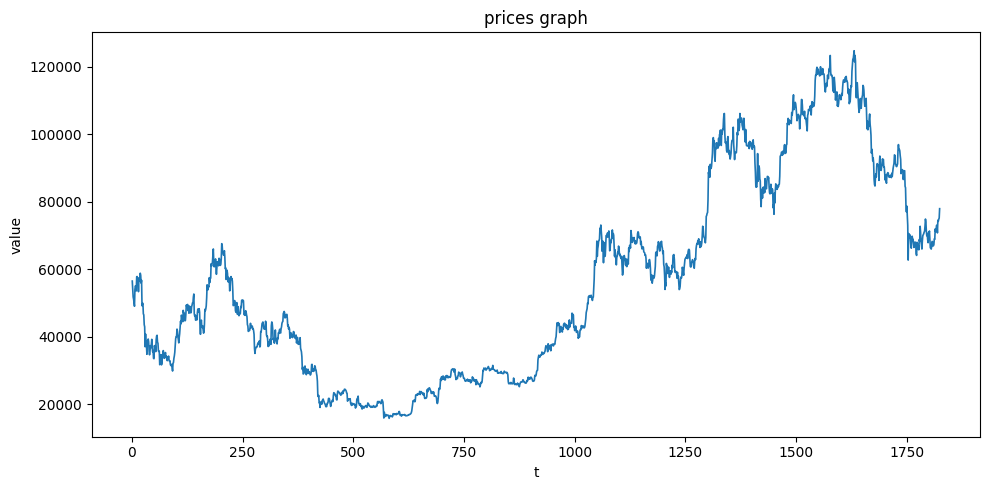

/tmp/ipykernel_3296/1378597442.py:87: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")
/tmp/ipykernel_3296/1378597442.py:75: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")


constant based stationairty report for price
   test  statistic   p_value          null
0   ADF  -0.985452  0.758533     unit root
1  KPSS   4.439368  0.010000  stationarity
constant plus time trend based stationairty report for price
   test  statistic   p_value          null
0   ADF  -2.034686  0.582419     unit root
1  KPSS   0.987389  0.010000  stationarity


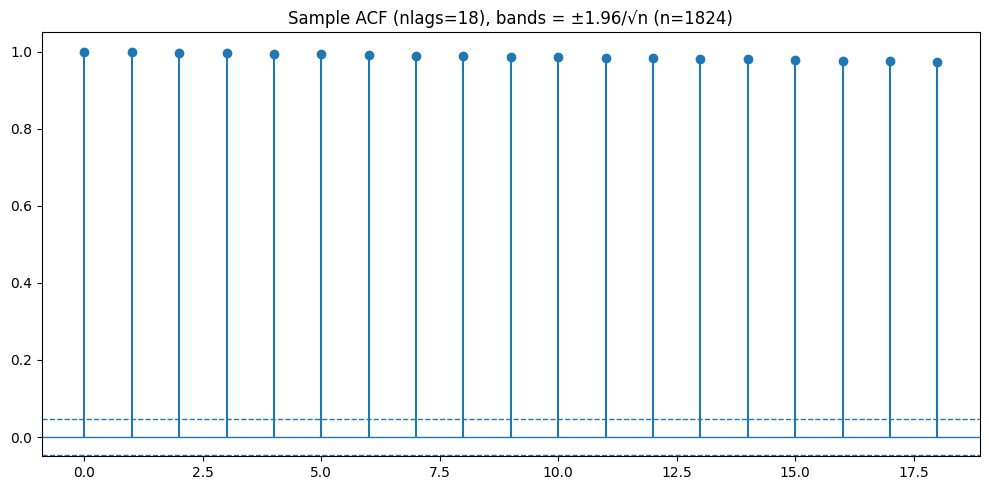

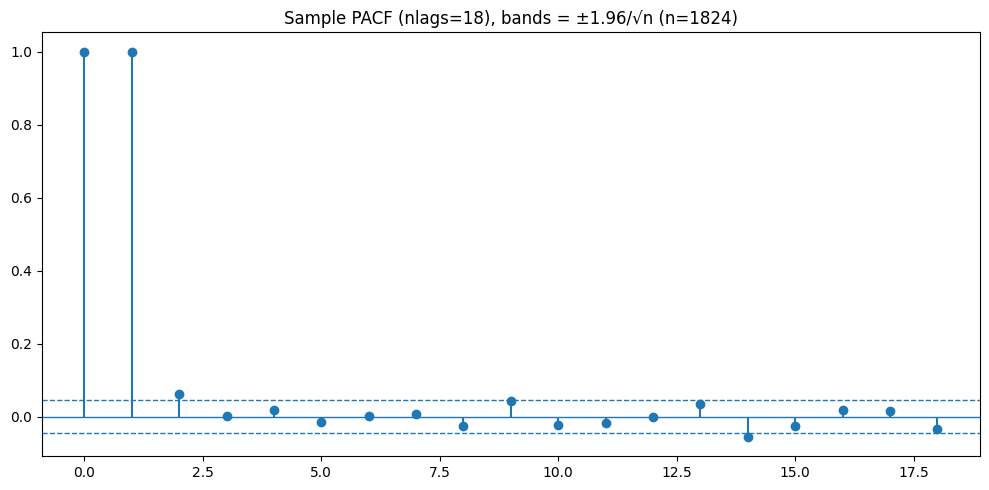

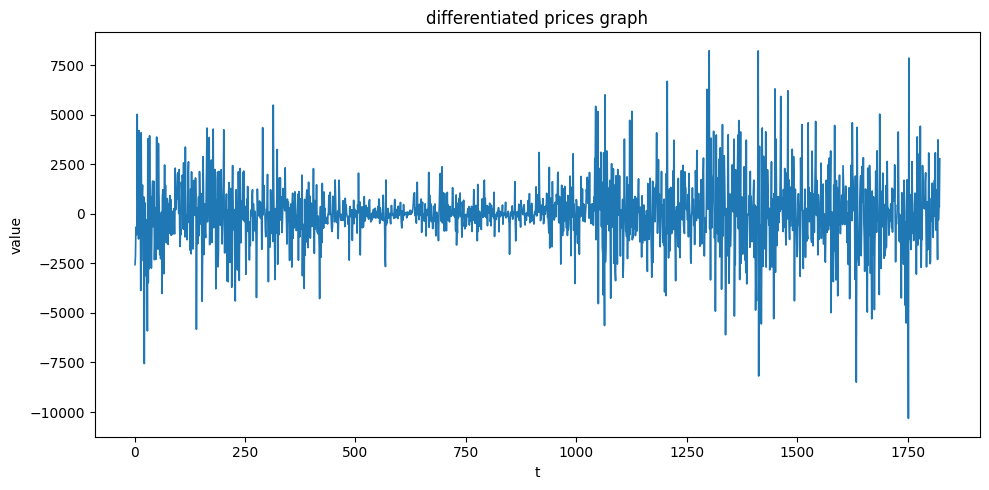

/tmp/ipykernel_3296/1378597442.py:87: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")


constant based stationairty report for differentiated price
   test  statistic  p_value          null
0   ADF -45.088304      0.0     unit root
1  KPSS   0.172798      0.1  stationarity
constant plus time trend based stationairty report for differentiated price
   test  statistic   p_value          null
0   ADF -45.082197  0.000000     unit root
1  KPSS   0.126752  0.085645  stationarity


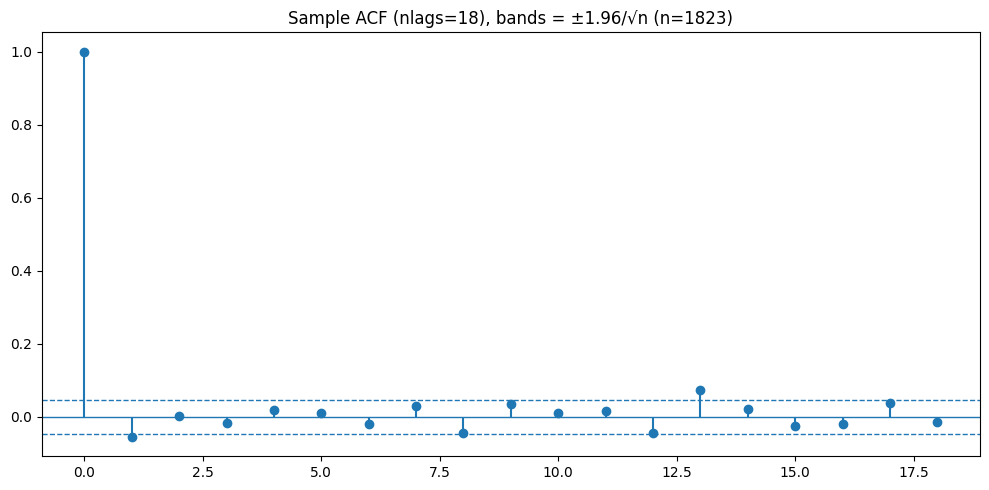

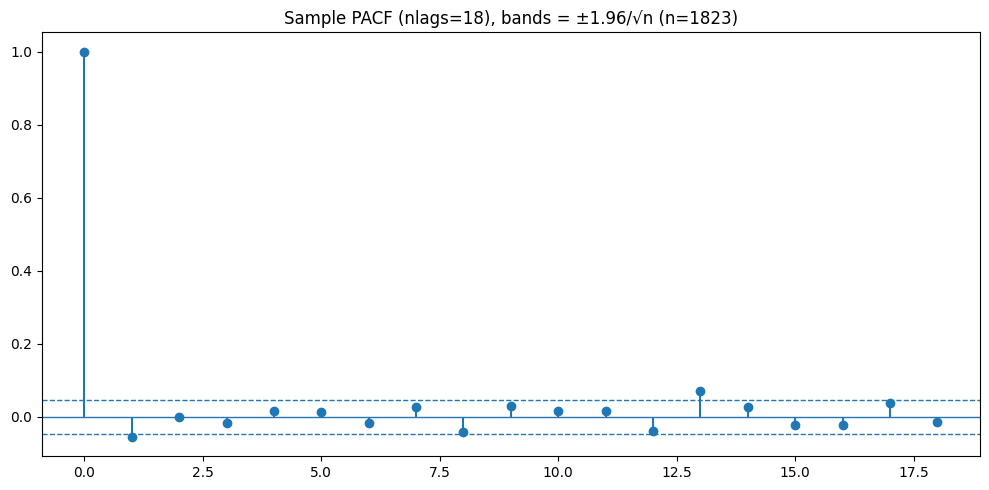

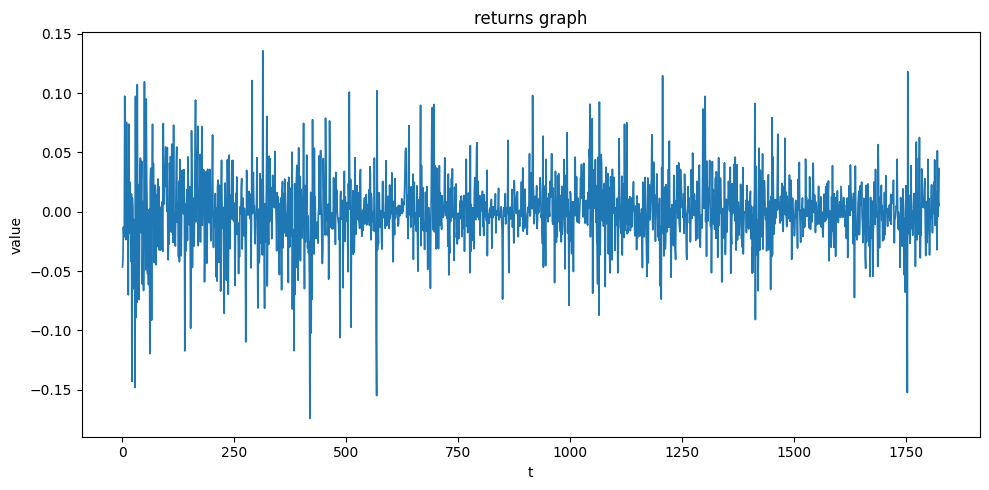

/tmp/ipykernel_3296/1378597442.py:87: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")


constant based stationarity report for log differenced price
   test  statistic       p_value          null
0   ADF  -8.368498  2.701973e-13     unit root
1  KPSS   0.235061  1.000000e-01  stationarity
constant plus time trend based stationairty report for log differenced price
   test  statistic       p_value          null
0   ADF  -8.394047  8.794374e-12     unit root
1  KPSS   0.141081  5.910872e-02  stationarity


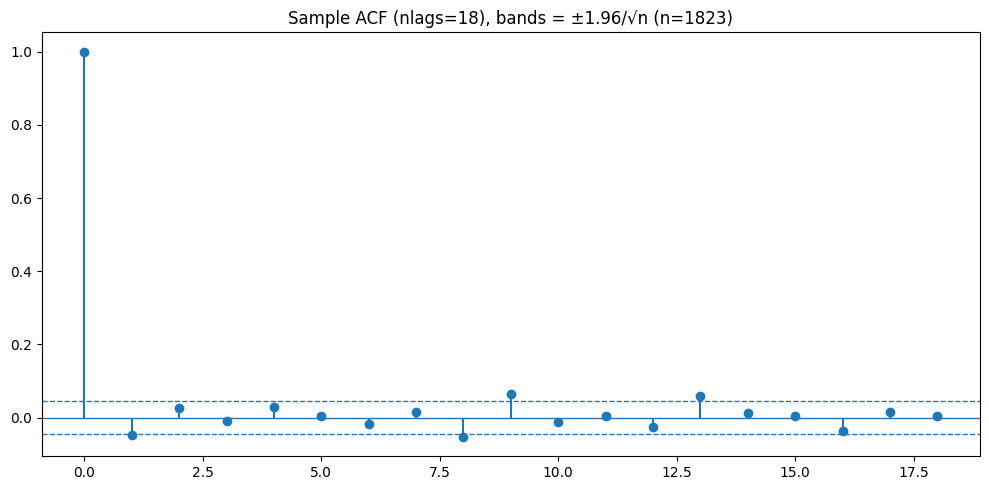

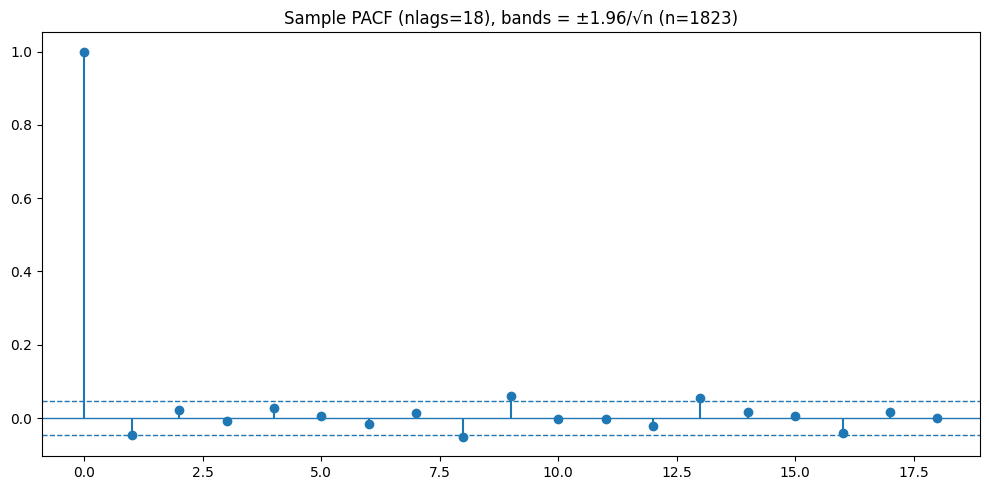

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1823
Model:                 ARIMA(1, 0, 0)   Log Likelihood                3842.972
Date:                Sun, 19 Apr 2026   AIC                          -7681.944
Time:                        08:42:15   BIC                          -7670.927
Sample:                             0   HQIC                         -7677.880
                               - 1823                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0471      0.017     -2.743      0.006      -0.081      -0.013
sigma2         0.0009   1.65e-05     52.278      0.000       0.001       0.001
Ljung-Box (L1) (Q):                   0.00   Jarque-

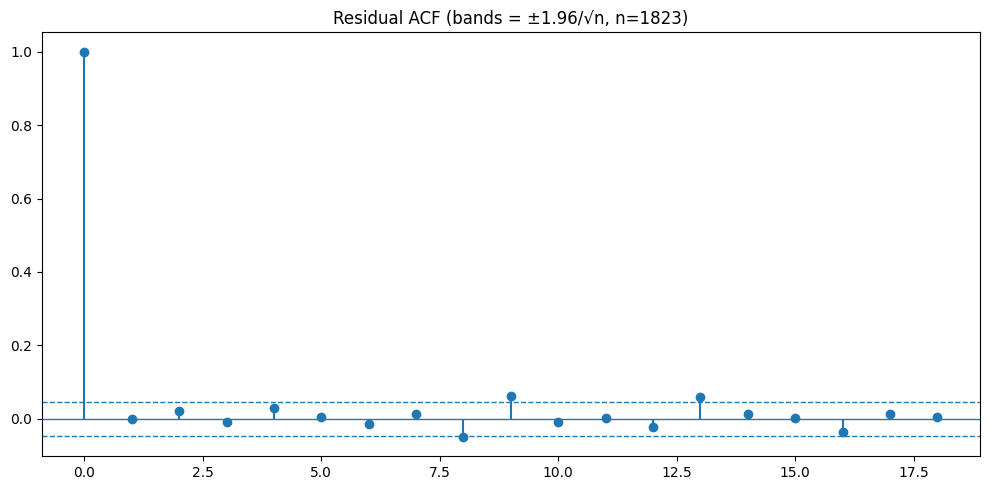

   Model  p  q          AIC          BIC
0   ARCH  1  0 -7750.269920 -7739.253443
1   ARCH  2  0 -7778.186134 -7761.661418
2  GARCH  1  1 -7868.450024 -7851.925308
3  GARCH  1  2 -7868.075441 -7846.042486
4  GARCH  2  1 -7872.280342 -7850.247387
5  GARCH  2  2 -7876.516987 -7848.975793


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0008639. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0008639. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
!pip install arch
from arch import arch_model
#download the latest data in local folder, then upload the same to google drive as this file does not contain the dataset in n in-built manner
df = pd.read_csv('/content/GroupProjectData(BTC_USD) (2).csv')
df.columns = ["date", "value"]
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date'])
df = df.sort_values('date')
#sort using dates
df = df.sort_values('date')
prices = df['value'].replace([np.inf, -np.inf], np.nan).dropna().values
plot_series(prices,'prices graph')
out0=c_adf_kpss_report(prices)
out1=ct_adf_kpss_report(prices)
print("constant based stationairty report for price")
print(out0)
print("constant plus time trend based stationairty report for price")
print(out1)
plot_acf_pacf(prices)
#take differencing of values
diff_prices = np.diff((prices))
diff_prices = diff_prices[np.isfinite(diff_prices)]
plot_series(diff_prices,'differentiated prices graph')
out2=c_adf_kpss_report(diff_prices)
out3=ct_adf_kpss_report(diff_prices)
print("constant based stationairty report for differentiated price")
print(out2)
print("constant plus time trend based stationairty report for differentiated price")
print(out3)
plot_acf_pacf(diff_prices)
#take log differencing of data
returns = np.diff(np.log(prices))
returns = returns[np.isfinite(returns)]
#check stationarity of log differenced values
plot_series(returns,'returns graph')
out4=c_adf_kpss_report(returns)
out5=ct_adf_kpss_report(returns)
print("constant based stationarity report for log differenced price")
print(out4)
print("constant plus time trend based stationairty report for log differenced price")
print(out5)
plot_acf_pacf(returns)
#select best model based on log differenced value
best_arma_fit, grid,list_of_fits=select_arma_model(returns)
print(best_arma_fit.summary())
#study the resuidual report from best model based on log difference data
required_resid,lb_info=residual_report(best_arma_fit)
lb_info
plot_resid_acf(required_resid)
#test for nonstationarity in residuals
arch_test = arch_lm_test(required_resid)
pd.DataFrame([arch_test])


def select_best_arch_garch(residuals, max_p=2, max_q=2, dist="normal"):

    residuals = np.asarray(residuals).flatten()

    results = []

    best_aic = np.inf
    best_bic = np.inf

    best_aic_model = None
    best_bic_model = None


    # ARCH(p)  (q = 0)

    for p in range(1, max_p + 1):
        try:
            model = arch_model(
                residuals,
                vol="ARCH",
                p=p,
                dist=dist,
                mean="Zero"
            )

            res = model.fit(disp="off")

            aic, bic = res.aic, res.bic
            results.append(["ARCH", p, 0, aic, bic])

            if aic < best_aic:
                best_aic = aic
                best_aic_model = ("ARCH", p, 0, aic, bic, res)

            if bic < best_bic:
                best_bic = bic
                best_bic_model = ("ARCH", p, 0, aic, bic, res)

        except Exception:
            continue


    # GARCH(p, q)  (q ≥ 1)

    for p in range(1, max_p + 1):
        for q in range(1, max_q + 1):
            try:
                model = arch_model(
                    residuals,
                    vol="GARCH",
                    p=p,
                    q=q,
                    dist=dist,
                    mean="Zero"
                )

                res = model.fit(disp="off")

                aic, bic = res.aic, res.bic
                results.append(["GARCH", p, q, aic, bic])

                if aic < best_aic:
                    best_aic = aic
                    best_aic_model = ("GARCH", p, q, aic, bic, res)

                if bic < best_bic:
                    best_bic = bic
                    best_bic_model = ("GARCH", p, q, aic, bic, res)

            except Exception:
                continue

    results_df = pd.DataFrame(
        results,
        columns=["Model", "p", "q", "AIC", "BIC"]
    )

    return best_aic_model, best_bic_model, results_df
Aic,bic,arch_garch_results=select_best_arch_garch(required_resid)
print(arch_garch_results)


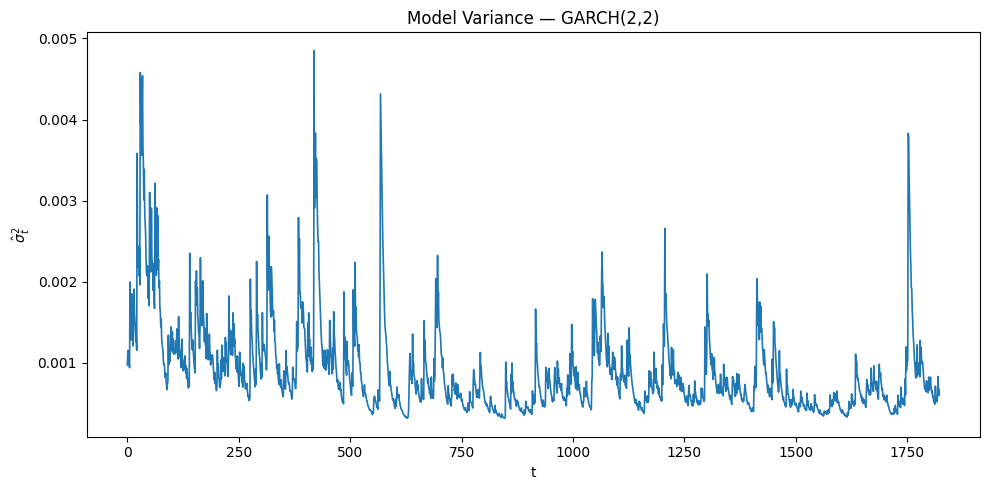

array([-1.71010259e-03,  8.05135774e-05, -3.79067092e-06,  1.78469104e-07,
       -8.40252867e-09,  3.95600619e-10, -1.86253277e-11])

In [ ]:
#find the optimal order for GARCH model, assign the same to helper function fit_garch_model in first cell, rerun the first cell and then re-run this cell
garch_fit = fit_garch_model(required_resid)
garch_fit
plot_conditional_variance(
    garch_fit["sig2"],
    title=f"Model Variance — {garch_fit['model']}"
)
h = 7
mean_fc_obj = best_arma_fit.get_forecast(steps=h)
mean_ret_fc = np.asarray(mean_fc_obj.predicted_mean)
mean_fc_obj
mean_ret_fc

code for above block is to find combination of optimal model for log differenced data, below block is to find combination of optimal model for normal differenced data

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1823
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -16070.510
Date:                Sun, 19 Apr 2026   AIC                          32145.020
Time:                        08:44:54   BIC                          32156.037
Sample:                             0   HQIC                         32149.085
                               - 1823                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0555      0.016     -3.530      0.000      -0.086      -0.025
sigma2      2.656e+06   4.97e+04     53.476      0.000    2.56e+06    2.75e+06
Ljung-Box (L1) (Q):                   0.00   Jarque-

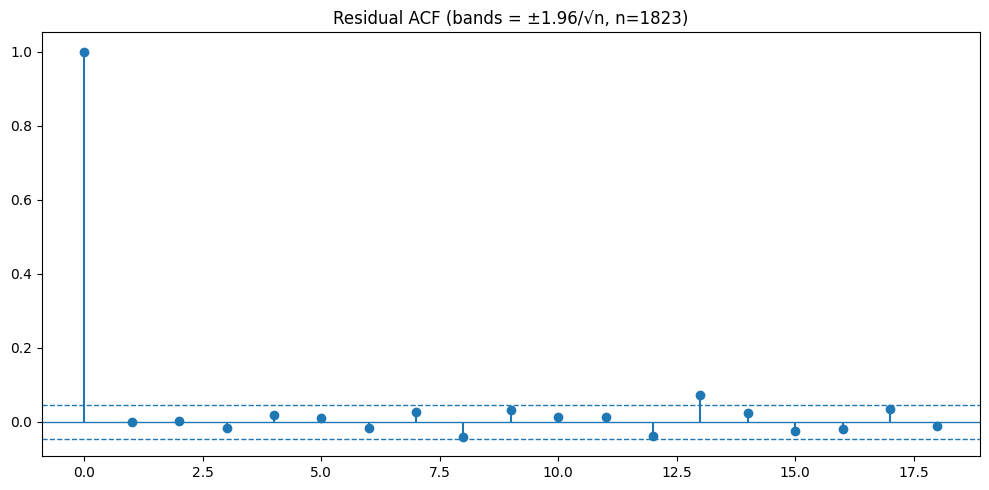

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.658e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.658e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/ba

   Model  p  q           AIC           BIC
0   ARCH  1  0  32034.455584  32045.472062
1   ARCH  2  0  31941.703149  31958.227865
2  GARCH  1  1  31534.622447  31551.147163
3  GARCH  1  2  31510.495635  31532.528590
4  GARCH  2  1  31469.981394  31492.014349
5  GARCH  2  2  31499.726683  31527.267877


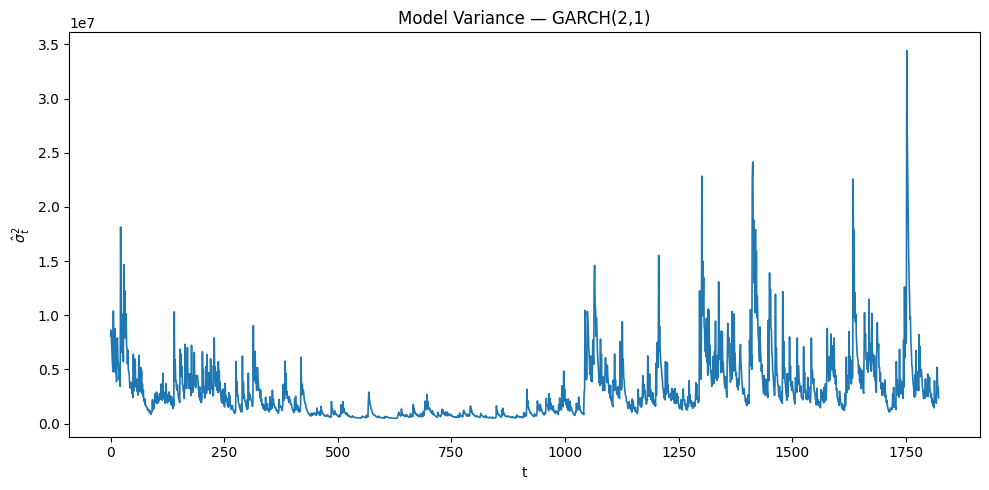

array([-1.71010259e-03,  8.05135774e-05, -3.79067092e-06,  1.78469104e-07,
       -8.40252867e-09,  3.95600619e-10, -1.86253277e-11])

In [ ]:
diff_best_arma_fit, grid,list_of_fits=select_arma_model(diff_prices)
print(diff_best_arma_fit.summary())
#study the residuual report from best model based on log difference data
reqd_resid,diff_lb_info=residual_report(diff_best_arma_fit)
diff_lb_info
plot_resid_acf(reqd_resid)
#test for nonstationarity in residuals
diff_arch_test = arch_lm_test(reqd_resid)
pd.DataFrame([diff_arch_test])
aic,Bic,diff_arch_garch_results=select_best_arch_garch(reqd_resid)
#find the optimal order for GARCH model, assign the same to helper function fit_diff_garch_model in first cell, rerun the first cell and then re-run this cell
print(diff_arch_garch_results)
garch_fit = fit_diff_garch_model(reqd_resid)
garch_fit
plot_conditional_variance(
    garch_fit["sig2"],
    title=f"Model Variance — {garch_fit['model']}"
)
h = 7
mean_fc_obj = best_arma_fit.get_forecast(steps=h)
mean_ret_fc = np.asarray(mean_fc_obj.predicted_mean)
mean_fc_obj
mean_ret_fc

In [ ]:

Z = {5: 1.96, 10: 1.645, 15: 1.44, 20: 1.28}

# CI — Log Returns (multiplicative)

def build_ci_log(P0, r_seq, sigma):
    r_sum = np.sum(r_seq)
    out = {"pred_price": P0 * np.exp(r_sum)}
    for k, z in Z.items():
        out[f"upper_{k}"] = P0 * np.exp(r_sum + z * sigma)
        out[f"lower_{k}"] = P0 * np.exp(r_sum - z * sigma)
    return out

# CI — Normal Diff (additive)

def build_ci_diff(P0, d_seq, sigma):
    d_sum = np.sum(d_seq)
    out = {"pred_price": P0 + d_sum}
    for k, z in Z.items():
        out[f"upper_{k}"] = P0 + d_sum + z * sigma
        out[f"lower_{k}"] = P0 + d_sum - z * sigma
    return out

def safe_garch_variance(garch, resid, p, q):

    # Case 1: GARCH failed or empty variance history
    if garch is None or "sig2" not in garch or len(garch["sig2"]) == 0:
        return np.array([np.var(resid)])

    # Case 2: Try normal forecast, fallback if it fails
    try:
        return forecast_garch_variance(
            garch["params"],
            resid,
            garch["sig2"],
            p=p,
            q=q,
            h=1
        )
    except Exception:
        return np.array([np.var(resid)])

#last value was till 17th April and we needed forecast till 24th April,if dataset is till 19th April put horizon as 5
def forecast_future_log(returns, prices, df, horizon=7):

    r_window  = list(np.array(returns))
    p_window  = list(np.array(prices))
    last_date = pd.Timestamp(df["date"].iloc[-1])

    daily_forecasts = []

    for i in range(horizon):
        #give optimal order manually for ARIMA here after making a note of the same in case of log differenced data
        arma  = ARIMA(r_window, order=(1, 0, 0)).fit()
        resid = arma.resid
        #give optimal order manually for GARCH in below mentioned function at first cell after making a note of the same in case of log differenced data
        garch = fit_garch_model(resid)

        r_fore = arma.forecast(steps=1)

        # Safe variance
        #give optimal order manually for GARCH here after making a note of the same in case of log differenced data
        var_fore = safe_garch_variance(garch, resid, p=2, q=2)

        sigma = np.sqrt(max(var_fore[0], 1e-8))
        P0    = p_window[-1]

        ci = build_ci_log(P0, r_fore, sigma)
        ci["date"] = last_date + pd.Timedelta(days=i + 1)
        ci["day"]  = f"Day {i+1}"

        daily_forecasts.append(ci)

        # Roll forward
        r_window.append(r_fore[0])
        p_window.append(ci["pred_price"])

    return pd.DataFrame(daily_forecasts).set_index("date")


#last value was till 17th April and we needed forecast till 24th April,if dataset is till 19th April put horizon as 5
def forecast_future_diff(diff_series, prices, df, horizon=7):

    d_window  = list(np.array(diff_series))
    p_window  = list(np.array(prices))
    last_date = pd.Timestamp(df["date"].iloc[-1])

    daily_forecasts = []

    for i in range(horizon):
        #give optimal order manually for GARCH here after making a note of the same in case of simple differenced data
        arma  = ARIMA(d_window, order=(0, 0, 1)).fit()
        resid = arma.resid
        #give optimal order manually for GARCH in below mentioned function at first cell after making a note of the same in case of simple differenced data
        garch = fit_diff_garch_model(resid)


        d_fore = arma.forecast(steps=1)

        #give optimal order manually for GARCH here after making a note of the same in case of simple differenced data
        var_fore = safe_garch_variance(garch, resid, p=2, q=1)

        sigma = np.sqrt(max(var_fore[0], 1e-8))
        P0    = p_window[-1]


        ci = build_ci_diff(P0, d_fore, sigma)
        ci["date"] = last_date + pd.Timedelta(days=i + 1)
        ci["day"]  = f"Day {i+1}"

        daily_forecasts.append(ci)


        d_window.append(d_fore[0])
        p_window.append(ci["pred_price"])

    return pd.DataFrame(daily_forecasts).set_index("date")


#last value was till 17th April and we needed forecast till 24th April,if dataset is till 19th April put horizon as 5
forecast_log  = forecast_future_log(returns, prices, df, horizon=7)
forecast_diff = forecast_future_diff(diff_prices, prices, df, horizon=7)
#date is in the format YYYY-MM-DD(year_number-month_number-date_number)
print("=== Log Returns Forecast ===")
print(forecast_log[-5:])
#date is in the format YYYY-MM-DD(year_number-month_number-date_number)
print("\n=== Diff Prices Forecast ===")
print(forecast_diff[-5:])

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== Log Returns Forecast ===
              pred_price       upper_5       lower_5      upper_10  \
date                                                                 
2026-04-20  77845.884692  81652.622682  74216.621150  81028.502302   
2026-04-21  77859.408741  81479.762898  74399.916175  80886.766151   
2026-04-22  77872.920499  81399.509214  74499.119289  80822.149228   
2026-04-23  77886.435163  81291.509851  74623.989559  80734.391808   
2026-04-24  77899.952018  81212.412930  74722.598497  80670.706475   

                lower_10      upper_15      lower_15      upper_20  \
date                                                                 
2026-04-20  74788.273155  80624.893559  75162.663738  80311.279245   
2026-04-21  74945.356553  80503.167855  75302.471829  80205.038514   
2026-04-22  75031.310166  80448.608608  75379.697076  80158.264671   
2026-04-23  75138.941987  80373.875513  75475.977034  80093.615887   
2026-04-24  75224.363211  80320.109802  75552.716988  80047.

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def backtest_last_5_only(log_returns, prices, horizon=5):

    log_returns = np.array(log_returns)
    prices = np.array(prices)

    # Train on everything except last 5
    train_r = list(log_returns[:-horizon])
    train_p = list(prices[:-horizon])

    future_actuals = prices[-horizon:]
    preds = []

    for step in range(horizon):

        #give optimal order manually for ARIMA here after making a note of the same in case of log differenced data
        arma = ARIMA(train_r, order=(1,0,0)).fit()
        resid = arma.resid

        garch = fit_garch_model(resid)

        # Forecast next return + volatility
        r_fore = arma.forecast(1)
        #give optimal order manually for GARCH here after making a note of the same in case of log differenced data
        var_fore = safe_garch_variance(garch, resid, p=2, q=2)


        P0 = train_p[-1]
        pred = P0 * np.exp(r_fore[0])
        preds.append(pred)


        train_r.append(r_fore[0])
        train_p.append(pred)

    preds = np.array(preds)
    actual = np.array(future_actuals)

    rmse = np.sqrt(np.mean((preds - actual)**2))
    mape = np.mean(np.abs((actual - preds) / actual)) * 100

    print("Backtest (Last 5 Days Only)")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")

    # Return results
    return pd.DataFrame({
        "actual": actual,
        "predicted": preds
    }), {"RMSE": rmse, "MAPE": mape}
df_backtest, metrics = backtest_last_5_only(returns, prices, horizon=5)
print(df_backtest)
print(metrics)

Backtest (Last 5 Days Only)
RMSE: 4628.6993
MAPE: 5.85%
        actual     predicted
0  74484.64063  70867.040524
1  74181.60938  70870.877374
2  74805.07813  70879.785391
3  75152.13281  70888.460397
4  77932.02344  70897.147151
{'RMSE': np.float64(4628.699317942718), 'MAPE': np.float64(5.8535076754892845)}


In [ ]:
#once you find optimal value for p and q for log simple differenced data, input it here
def backtest_last_5_rolling(diff_series, prices, horizon=5, p=2, q=1):

    diff_series = np.array(diff_series)
    prices      = np.array(prices)

    preds          = []
    future_actuals = prices[-horizon:]

    for step in range(horizon):


        end_idx = len(diff_series) - horizon + step  # grows by 1 each step
        train_d = list(diff_series[:end_idx])
        P0      = prices[end_idx - 1]


        # give optimal order manually for ARIMA here after making a note of the same in case of simple differenced data

        arma  = ARIMA(train_d, order=(0, 0, 1)).fit()
        resid = arma.resid


        # Refit GARCH on actual residuals

        garch = fit_diff_garch_model(resid, p=p, q=q)


        # 1-step-ahead forecast only

        d_fore   = arma.forecast(steps=1)
        var_fore = safe_garch_variance(garch, resid, p=p, q=q)

        sigma      = np.sqrt(max(var_fore[0], 1e-8))
        pred_price = P0 + d_fore[0]
        preds.append(pred_price)

    preds  = np.array(preds)
    actual = np.array(future_actuals)

    rmse = np.sqrt(np.mean((preds - actual) ** 2))
    mae  = np.mean(np.abs(preds - actual))
    mape = np.mean(np.abs((actual - preds) / actual)) * 100

    print("Backtest — True Rolling Forecast (Last 5 Days)")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return pd.DataFrame({
        "actual":    actual,
        "predicted": preds,
        "error":     preds - actual
    }), {"RMSE": rmse, "MAE": mae, "MAPE": mape}


df_backtest, metrics = backtest_last_5_rolling(diff_prices, prices, horizon=5)
print(df_backtest)
print(metrics)

Backtest — True Rolling Forecast (Last 5 Days)
RMSE: 2267.3220
MAE : 1870.5774
MAPE: 2.48%
        actual     predicted        error
0  74484.64063  73186.472576 -1298.168054
1  74181.60938  70563.037248 -3618.572132
2  74805.07813  74500.633732  -304.444398
3  75152.13281  74157.792681  -994.340129
4  77932.02344  74794.661339 -3137.362101
{'RMSE': np.float64(2267.3219537024843), 'MAE': np.float64(1870.5773628987372), 'MAPE': np.float64(2.47534235729891)}
